### Assignment 2

In [20]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install opencv-python
!pip install nltk
!pip install librosa
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import nltk
import librosa

## **Following code is taken from Lab 2 but rerun for the purposes of Assignment 2**

Importing Libraries

In [2]:
#importing the required libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa.display
import soundfile
import os

from glob import glob

import librosa
import IPython.display as ipd


Download the dataset from the [audio dataset folder.](https://1sfu-my.sharepoint.com/:f:/g/personal/oyalcin_sfu_ca/ErKIxg5g4rFOlfrAZ352DW4BD1ytBiz1kZLcj5Elk9_1rQ?e=lgUQoi)

### Load the Dataset and Compute Features
We have to understand the labelling of the RAVDESS dataset to find the ground truth emotion for each sample.
Each file is labelled with 7 numbers delimited by a "-".
Most of the numbers describe metadata about the audio samples such as their format (video and/or audio),
whether the audio is a song or statement, which of two statements is being read and by which actor.

The third and fourth numbers pertain to the emotional quality of each sample. The third number is in the range of 1-8 with each number representing an emotion.
The fourth number is either 1 or 2, representing normal (1) or strong (2) emotional intensity.

When you upload your own data, you should be using this convention.

We're going to define a dictionary based on the third number (emotion) and assign an emotion to each number as specified by the RAVDESS dataset:

In [3]:
# audio_files = glob('Audio Data/Audio Data/*/*.wav') 
audio_files = glob('***')  # Change to your own filepath with "/Audio Data/*/*
# * means taking whatever folders are in the directory; we want to get all of the actors in the 
# folder so basically this is saying that within Audio Data/Audio Data, go through every folder and take the ones with the .wav extension


#Playing an audio file using IPython.display
ipd.Audio(audio_files[0])

In [32]:
#Emotions in the RAVDESS dataset
emotions_dict ={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

Now we're going to load our data and extract the emotion names according to the list we provided above.

In [33]:
import os, glob

def load_data():
    X,y=[],[]
    count = 0
    for file in glob.glob("***"): # Change to your own filepath with "/Audio Data/*/*
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1440} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

We will not compute the feature matrix this week, but we will read the emotion labels for the entire dataset.
We will explain why the X and Y elements are important in the upcoming weeks.

In [34]:
features, emotions = load_data()

 Processed 1439/1440 audio samples 

### Going to rerun lab code but add a title to this graph.

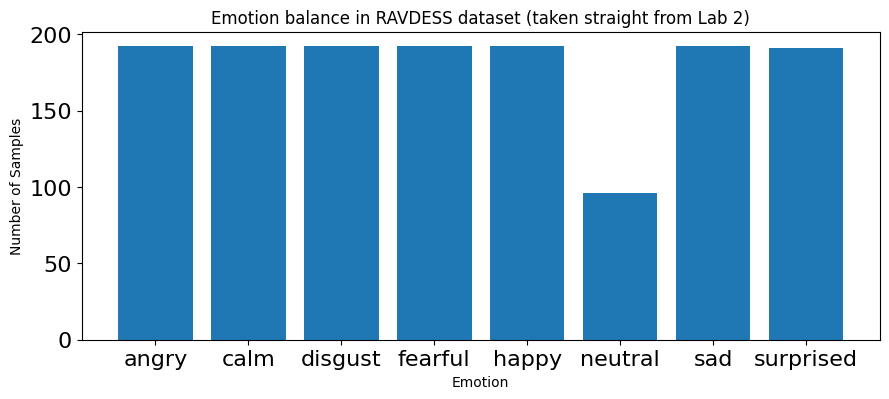

In [35]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.title('Emotion balance in RAVDESS dataset (taken straight from Lab 2)')
plt.show()

**Now that sanity checking of lab material done (I reran the initial tutorial code with edits to match my own file directory), let's movie on to new data using my voice dataset.**


In [20]:
#importing the required libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa.display
import soundfile
import os

from glob import glob

import librosa
import IPython.display as ipd

In [21]:
# audio_files = glob('Audio Data/Audio Data/*/*.wav') 
new_audio_files = glob("***") #Change to your own filepath with "Audio Data New/*.wav"
# * means taking whatever folders are in the directory; we want to get all of the actors in the 
# folder so basically this is saying that within Audio Data/Audio Data, go through every folder and take the ones with the .wav extension


#Playing an audio file using IPython.display
ipd.Audio(new_audio_files[0])

In [22]:
import os, glob

def load_new_data_only():
    X,y=[],[]
    count = 0
    for file in glob.glob('***'): # Change to your own filepath with /"Audio Data New/*.wav"
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]] 
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{32} audio samples',end=' ') # Should be 34 audio samples.
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [23]:
features, emotions = load_new_data_only()

 Processed 32/32 audio samples 

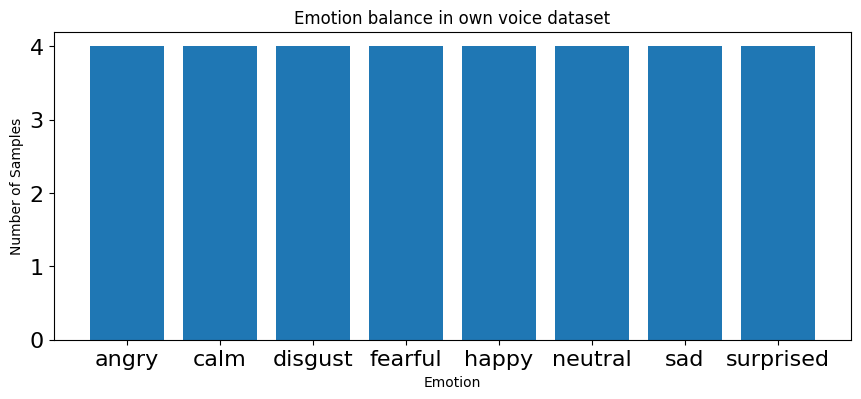

In [25]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.title('Emotion balance in own voice dataset')
plt.show()

I have recorded four takes per emotion; two takes for the first line and two takes for the second line, resulting in a balanced spread of samples across all emotions.

**COMBINING DATA**

In [26]:
def load_combined_data():
    X,y=[],[]
    count = 0
    for file in glob.glob("***"): # Get RAVDESS Dataset
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line

    for file in glob.glob('***'): # Get own Dataset
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1471} audio samples',end=' ') # Should be 32 audio samples.
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [27]:
features, emotions = load_combined_data()

 Processed 1471/1471 audio samples 

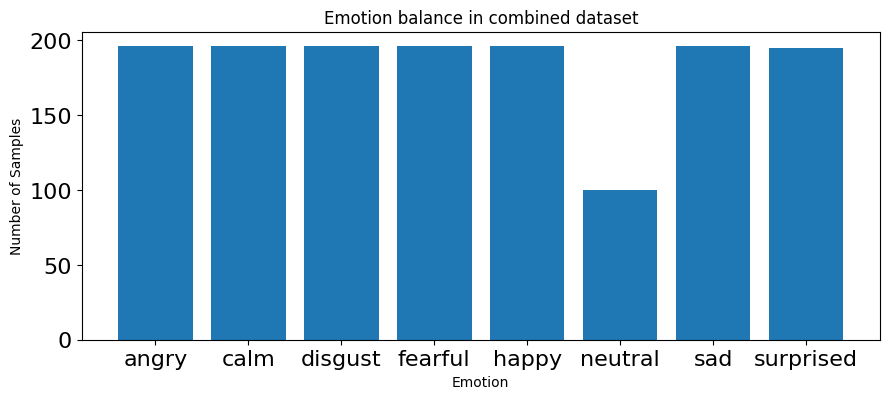

In [28]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.title('Emotion balance in combined dataset')
plt.show()

**VOICE CHECKING**

In order to differentiate between male and female voices, let's declare a new dictionary.

In [10]:
#Emotions in the RAVDESS dataset
voices_dict ={
  '01':'male',
  '02':'female'
}

In [13]:
import os, glob

# Simple check if even or odd
def check_gender(voice):
    voice = voice.replace(".wav", "") # Have to remove the .wav from what's left after using the split() function.
    if(int(voice) % 2 == 0):
        return '02'
    return '01'

def load_voices_data():
    X,y=[],[]
    count = 0
    for file in glob.glob("***): # Get RAVDESS Dataset
        file_name=os.path.basename(file)
        # The key is in this line; emotion was denoted by the 3rd number (separated by "-" in each audio file), so index 2 was used.
        # Therefore, for tracking gender, use index 6 as it is the 7th number.
        voice=voices_dict[check_gender(file_name.split("-")[6])]
        #features = get_features(file)
        #X.append(features)
        y.append(voice)
        count += 1
        # '\r' + end='' results in printing over same line

    for file in glob.glob('***'): # Get own Dataset
        file_name=os.path.basename(file)
        voice=voices_dict[check_gender(file_name.split("-")[6])]
        #features = get_features(file)
        #X.append(features)
        y.append(voice)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1471} audio samples',end=' ') # Should be 32 audio samples.
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [14]:
features, voices = load_voices_data()

 Processed 1471/1471 audio samples 

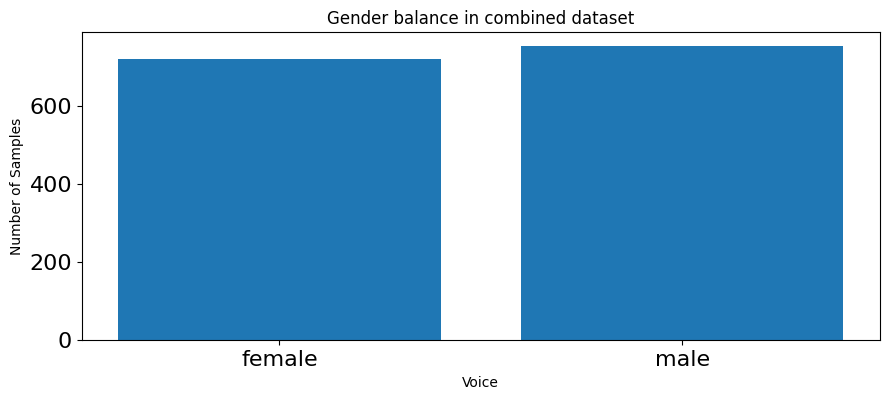

In [15]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
voice_list, count = np.unique(voices, return_counts=True)
plt.bar(x=range(2), height=count) # Using range of 2
plt.xticks(ticks=range(2), labels = [voice for voice in voice_list],fontsize=10)
plt.xlabel('Voice')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.title('Gender balance in combined dataset')
plt.show()